#Import Libraries


In [15]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score
import joblib

#Data Loading and Formatting

In [16]:
#Data Loading
housing = fetch_california_housing()

# DataFrame

df = pd.DataFrame(housing.data, columns=housing.feature_names)

#Adding the Target Column
df['MedHouseVal'] = housing.target

pd.set_option('display.width', 1000)

print(df.head(10))


   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  Longitude  MedHouseVal
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88    -122.23        4.526
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86    -122.22        3.585
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85    -122.24        3.521
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85    -122.25        3.413
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85    -122.25        3.422
5  4.0368      52.0  4.761658   1.103627       413.0  2.139896     37.85    -122.25        2.697
6  3.6591      52.0  4.931907   0.951362      1094.0  2.128405     37.84    -122.25        2.992
7  3.1200      52.0  4.797527   1.061824      1157.0  1.788253     37.84    -122.25        2.414
8  2.0804      42.0  4.294118   1.117647      1206.0  2.026891     37.84    -122.26        2.267
9  3.6912      52.0  4.970588 

In [17]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


#Feature and Target Selection

In [18]:
# Dropping the target column to keep only the features in X

X = df.drop('MedHouseVal', axis=1)


#Assigning the "MedHouseVal" column as our label or target variable y

y = df['MedHouseVal']

#Splitting Dataset for Training and Testing

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Model Training

In [20]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

#Model Evaluation

In [21]:
# Making predictions on the test set

y_pred = model.predict(X_test)

# Calculating the evaluation metrics

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)


print(f"Mean Squared Error: {mse}")
print(f"R-Squared (Accuracy) Score: {r2}")

Mean Squared Error: 0.5558915986952443
R-Squared (Accuracy) Score: 0.5757877060324508


## Feature Scaling

In [22]:
# Scaling the data

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaler = scaler.transform(X_test)

##Random Forest Model

In [23]:
# Model Training with Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Making predictions using the TEST set (X_test_scaled)
rf_pred = rf_model.predict(X_test_scaler)

# Model Evaluation
# Now rf_pred and y_test will both have 4128 samples
rf_mse = mean_squared_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print(f"Random Forest Mean Squared Error: {rf_mse}")
print(f"Random Forest R-Squared (Accuracy) Score: {rf_r2}")

Random Forest Mean Squared Error: 0.255169737347244
Random Forest R-Squared (Accuracy) Score: 0.8052747336256919


##Feature Importance

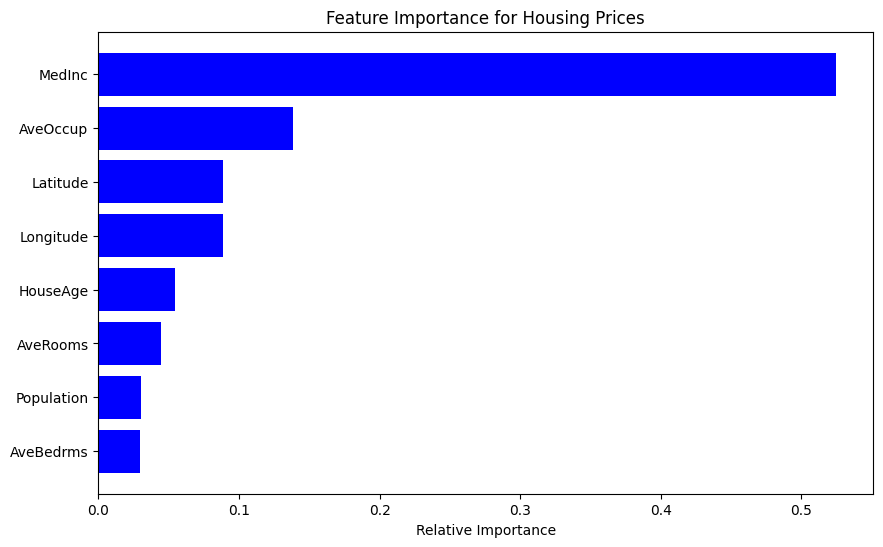

In [24]:
#Getting feature importance from the forest model
importances = rf_model.feature_importances_
feature_names= df.drop('MedHouseVal', axis=1).columns



#Sorting and ploting
indices = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.title('Feature Importance for Housing Prices')
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

##Hyperparameter Tuning

In [11]:
# Training with more trees (n_estimators=200)
rf_model_tuned = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model_tuned.fit(X_train_scaled, y_train)

# Accuracy Check
tuned_score = rf_model_tuned.score(X_test_scaler, y_test)
print(f"Tuned Random Forest Accuracy: {tuned_score}")

Tuned Random Forest Accuracy: 0.8063074586513359


##Cross-Validation

In [12]:
# Performing 5-fold cross-validation
cv_scores = cross_val_score(rf_model, X_train_scaled, y_train, cv=5)

print(f"Cross-Validation Score: {cv_scores}")
print(f"Average CV Accuracy: {cv_scores.mean()}")

Cross-Validation Score: [0.80901645 0.79413815 0.80825595 0.80432529 0.80510896]
Average CV Accuracy: 0.8041689588513355


## Model Prediction

In [13]:
# 1. New data input (Example: giving values for all features)
# Features: MedInc, HouseAge, AveRooms, AveBedrms, Population, AveOccup, Latitude, Longitude
new_house_data = [[4.5, 40.0, 5.5, 3.0, 1000.0, 5.8, 34.0, -118.0]]

# 2. Scaling the new data (IMPORTANT: You must scale before predicting)
new_house_scaled = scaler.transform(new_house_data)

# 3. Making the prediction using Random Forest Model
predicted_price = rf_model.predict(new_house_scaled)

# 4. Displaying the result
print(f"The predicted price of the house is: ${predicted_price[0]:.2f} (in 100,000s)")

The predicted price of the house is: $2.04 (in 100,000s)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


##Model Saving

In [14]:
#Saving the final tuned model
joblib.dump(rf_model_tuned, 'california_housing_final_model.pkl')

#Saving the scaler (This is essential to scale future new inputs)
joblib.dump(scaler, 'housing_scaler.pkl')

print("Final Model and Scaler have been saved successfully!")

Final Model and Scaler have been saved successfully!
